In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install transformers datasets accelerate evaluate -q

In [ ]:
import pandas as pd
import numpy as np

import torch

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [ ]:
final_df = pd.read_csv(
    "/content/drive/MyDrive/FP_AI_2026/FinalDataset.csv"
)

print(final_df.shape)

final_df.head()

(1000, 5)


,problem_id,Sample_Code,Generated,Language,Source
0,Prob3353,import Java.util.*;\npublic class Main {\n\tpu...,Human,Java,CodeNet
1,Prob6275,#include <stdio.h>\n#include <string.h>\n#incl...,AI,C,ChatGPT-4
2,Prob97,import Java.util.Scanner;\n\npublic class Mood...,AI,Java,ChatGPT-4
3,Prob5190,#include <bits/stdc++.h>\nusing namespace std;...,Human,C++,CodeNet
4,Prob1082,"N,M=map(int,input().split())\nL,R=map(int,inpu...",Human,Python,CodeNet


In [ ]:
le = LabelEncoder()

final_df["Label"] = le.fit_transform(
    final_df["Generated"]
)

print(
    final_df["Label"].value_counts()
)

print(le.classes_)

Label
1    500
0    500
Name: count, dtype: int64
['AI' 'Human']


In [ ]:
train_df, test_df = train_test_split(
    final_df,
    test_size=0.2,
    random_state=42,
    stratify=final_df["Label"]
)

print(train_df.shape)
print(test_df.shape)

(800, 6)
(200, 6)


In [ ]:
MODEL_NAME = "microsoft/graphcodebert-base"

tokenizer = AutoTokenizer.from_pretrained( # load tokenizer

    MODEL_NAME
)

In [ ]:
train_encodings = tokenizer( # tokenisasi data
    train_df["Sample_Code"].tolist(), # mengubah kolom pandas menjadi list Python biasa.
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    test_df["Sample_Code"].tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

In [ ]:
class CodeDataset(torch.utils.data.Dataset): # data ke format PyTorch/Trainer

    def __init__( # menyimpan encodings dan labels sebagai atribut class.
        self,
        encodings,
        labels
    ):
        self.encodings = encodings # hasil tokenisasi
        self.labels = labels # list angka 0/1

    def __getitem__(self, idx): # ambil semua nilai encoding, ubah menjadi tensor, tambah label

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels[idx]
        )

        return item

    def __len__(self):

        return len(self.labels) # Mengembalikan total sampel

In [ ]:
train_dataset = CodeDataset( # Membuat objek dataset dari class yang sudah didefinisikan.
    train_encodings,
    train_df["Label"].tolist()
)

test_dataset = CodeDataset(
    test_encodings,
    test_df["Label"].tolist()
)

In [ ]:
# Load model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: microsoft/graphcodebert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# cek jumlah parameter

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("=" * 50)
print("MODEL COMPLEXITY")
print("=" * 50)

print(
    f"Total Parameters: {total_params:,}"
)

print(
    f"Trainable Parameters: {trainable_params:,}"
)

MODEL COMPLEXITY
Total Parameters: 124,647,170
Trainable Parameters: 124,647,170


In [ ]:
# fungsi metrik

def compute_metrics(pred):

    labels = pred.label_ids

    preds = pred.predictions.argmax(-1)

    probs = torch.softmax(
        torch.tensor(pred.predictions),
        dim=1
    )[:,1].numpy()

    acc = accuracy_score(
        labels,
        preds
    )

    precision = precision_score(
        labels,
        preds
    )

    recall = recall_score(
        labels,
        preds
    )

    f1 = f1_score(
        labels,
        preds
    )

    auc = roc_auc_score(
        labels,
        probs
    )

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc
    }

In [ ]:
training_args = TrainingArguments(
    output_dir="./graphcodebert_results", # penyimpanan checkpoint

    eval_strategy="epoch", # eval setiap 1 epoch

    save_strategy="epoch",

    load_best_model_at_end=True, # training selesai, load ulang model terbaik

    metric_for_best_model="f1", # model terbaik = yang punya F1 tertinggi

    greater_is_better=True,

    learning_rate=2e-5, # kecil, s

    per_device_train_batch_size=8, # proses 8 sampel sekaligus

    per_device_eval_batch_size=8,

    num_train_epochs=5, # training 5 putaran

    weight_decay=0.01,

    logging_steps=20, # cetak log setiap 20 step

    save_total_limit=2, # maksimal simpan 2 checkpoint terakhir

    report_to="none"
)

In [ ]:
# menggabungkan model + konfigurasi + data + metrik
trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics
)

In [ ]:
# jalankan fine tunning

import time

start_train = time.time()

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auc
1,0.155935,0.136454,0.955000,0.969072,0.940000,0.954315,0.989100
2,0.032114,0.147835,0.965000,1.000000,0.930000,0.963731,0.986400
3,0.053636,0.103412,0.980000,1.000000,0.960000,0.979592,0.992900
4,0.001002,0.177069,0.965000,1.000000,0.930000,0.963731,0.988100
5,0.000811,0.120319,0.975000,1.000000,0.950000,0.974359,0.990800


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=500, training_loss=0.10193848084285856, metrics={'train_runtime': 533.0528, 'train_samples_per_second': 7.504, 'train_steps_per_second': 0.938, 'total_flos': 526222110720000.0, 'train_loss': 0.10193848084285856, 'epoch': 5.0})

In [ ]:
# hitung training time

training_time = (
    time.time() - start_train
)

print(
    f"Training Time: {training_time:.2f} seconds"
)

Training Time: 584.96 seconds


In [ ]:
# hitung inference time

start_inference = time.time()

predictions = trainer.predict(
    test_dataset
)

inference_time = (
    time.time() - start_inference
)

print(
    f"Inference Time: {inference_time:.4f} seconds"
)

Inference Time: 3.4536 seconds


In [ ]:
# ambil prediksi final

predictions = trainer.predict(
    test_dataset
)

y_pred = np.argmax(
    predictions.predictions,
    axis=1 # argmax = 0 (AI), argmax = 1 (human)
)

y_true = test_df["Label"].values # label asli dari test set sebagai pembanding

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["AI","Human"]
    )
)

              precision    recall  f1-score   support

          AI       0.96      1.00      0.98       100
       Human       1.00      0.96      0.98       100

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



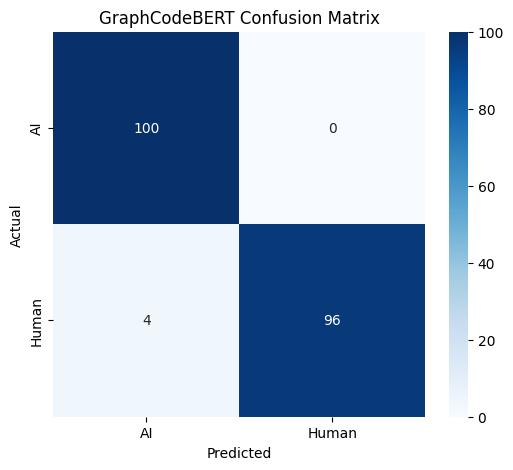

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(
    figsize=(6,5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["AI","Human"],
    yticklabels=["AI","Human"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GraphCodeBERT Confusion Matrix")

plt.show()

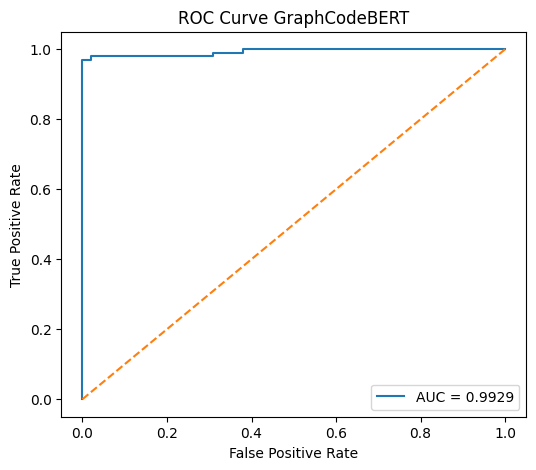

In [ ]:
from sklearn.metrics import roc_curve

probs = torch.softmax(
    torch.tensor(predictions.predictions),
    dim=1
)[:,1].numpy()

fpr, tpr, _ = roc_curve(
    y_true,
    probs
)

plt.figure(
    figsize=(6,5)
)

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_true, probs):.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve GraphCodeBERT")

plt.legend()

plt.show()

In [ ]:
trainer.save_model(
    "/content/drive/MyDrive/FP_AI_2026/models/GraphCodeBERT_Model"
)

tokenizer.save_pretrained(
    "/content/drive/MyDrive/FP_AI_2026/models/GraphCodeBERT_Model"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/FP_AI_2026/models/GraphCodeBERT_Model/tokenizer_config.json',
 '/content/drive/MyDrive/FP_AI_2026/models/GraphCodeBERT_Model/tokenizer.json')

In [ ]:
print(results)

{'eval_loss': 0.10351814329624176, 'eval_accuracy': 0.98, 'eval_precision': 1.0, 'eval_recall': 0.96, 'eval_f1': 0.9795918367346939, 'eval_auc': 0.9929, 'eval_runtime': 3.1291, 'eval_samples_per_second': 63.916, 'eval_steps_per_second': 7.99, 'epoch': 5.0}


In [ ]:
compare_path = (
    "/content/drive/MyDrive/FP_AI_2026/compare"
)

graph_results = pd.DataFrame([
    {
        "Model":
            "GraphCodeBERT",

        "Accuracy":
            results["eval_accuracy"],

        "Precision":
            results["eval_precision"],

        "Recall":
            results["eval_recall"],

        "F1":
            results["eval_f1"],

        "AUC":
            results["eval_auc"],

        "Training_Time":
            training_time,

        "Inference_Time":
            inference_time,

        "Parameters":
            total_params
    }
])

graph_results

,Model,Accuracy,Precision,Recall,F1,AUC,Training_Time,Inference_Time,Parameters
0,GraphCodeBERT,0.98,1.0,0.96,0.979592,0.9929,584.956421,3.453578,124647170


In [ ]:
graph_results.to_csv(
    f"{compare_path}/graphcodebert_results.csv",
    index=False
)

print(
    "GraphCodeBERT results saved"
)

GraphCodeBERT results saved
